In [9]:
# ==========================================
# 1. Importar librerías
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


        fecha  volumen     variedad                    zona  volumen_log  \
0  2026-02-03     18.0  Papa Blanca                   pasco     2.944439   
1  2026-02-03     10.0  Papa Blanca  daniel alcides carrion     2.397895   
2  2026-02-03     60.0  Papa Blanca                    lima     4.110874   
3  2026-02-03     19.0  Papa Blanca                  huaura     2.995732   
4  2026-02-03     38.0   Papa Unica                  huaral     3.663562   

  region  precio_promedio_kg  indice_precio_diesel  lluvia_hoy  \
0  pasco                0.94               88.4916       12.51   
1  pasco                0.94               88.4916       12.67   
2   lima                0.94               88.4916        0.45   
3   lima                0.94               88.4916        3.34   
4   lima                1.48               88.4916        1.43   

   dias_con_helada_en_cultivo    T2M  T2M_MIN  T2M_MAX  
0                         0.0   6.31     2.17    11.14  
1                         0.0   

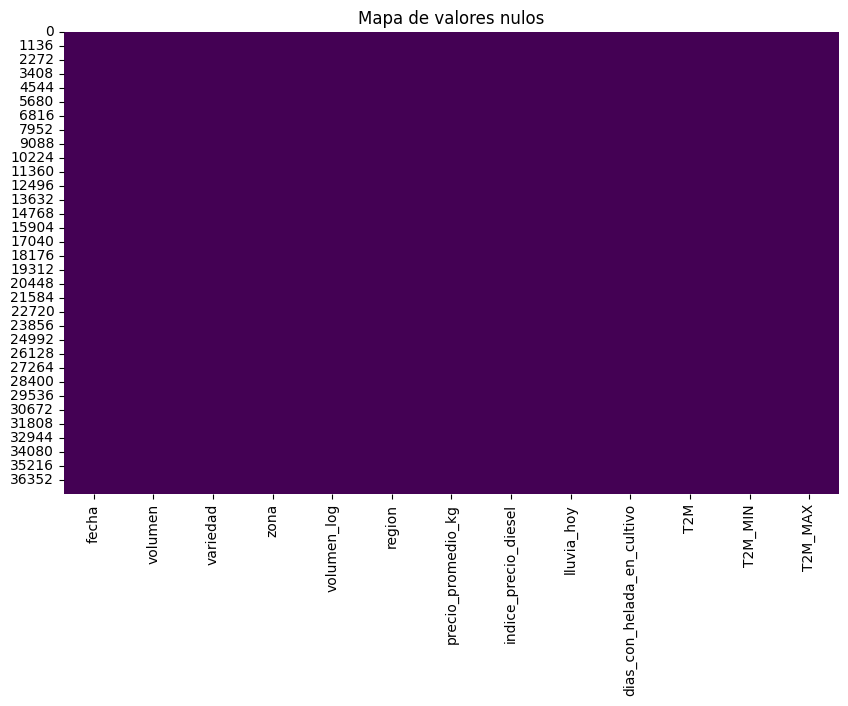

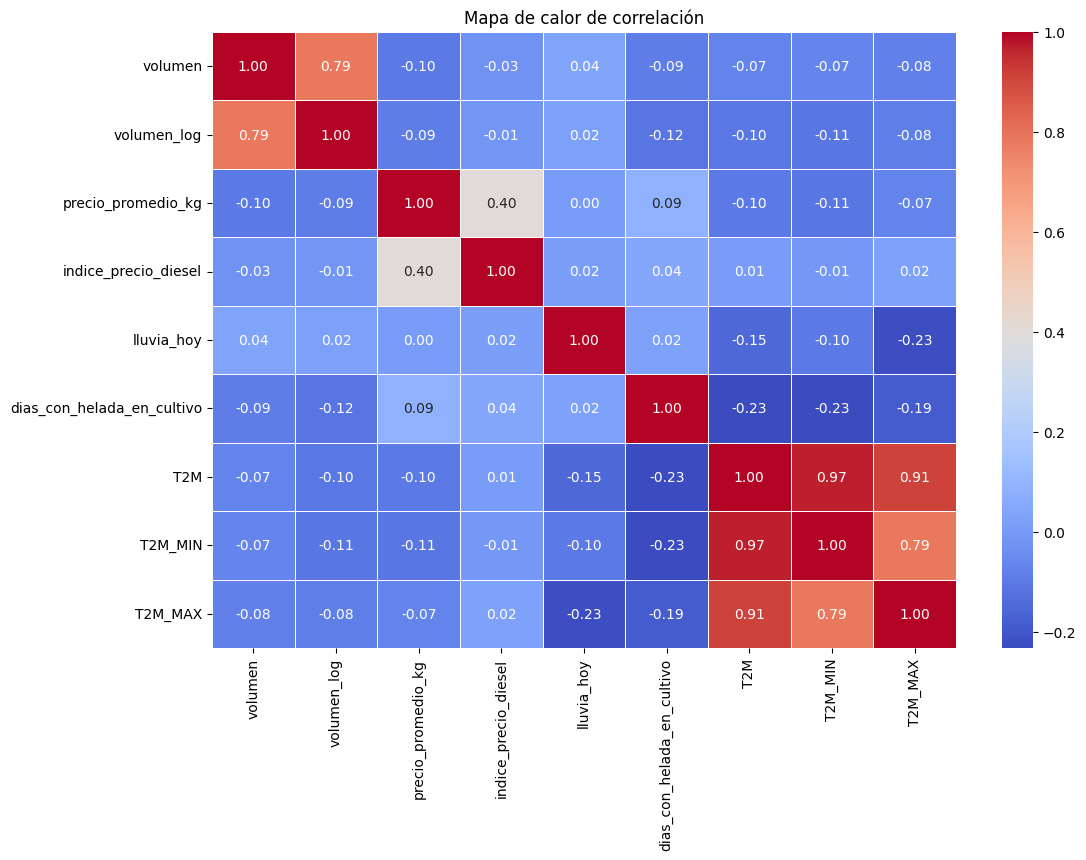

In [1]:


# ==========================================
# 2. Cargar dataset
# ==========================================
df = pd.read_csv("Dataset_Final_Modelado.csv")

# Mostrar las primeras filas
print(df.head())

# ==========================================
# 3. Análisis de valores nulos
# ==========================================

print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())

print("\nPorcentaje de valores nulos:")
print((df.isnull().sum()/len(df)*100).round(2))

# Visualización de nulos
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores nulos")
plt.show()

# ==========================================
# 4. Mapa de calor de variables numéricas
# ==========================================

# Seleccionar únicamente columnas numéricas
df_numericas = df.select_dtypes(include=['int64','float64'])

# Matriz de correlación
corr = df_numericas.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Mapa de calor de correlación")
plt.show()



In [3]:
# ==========================================
# 5. Eliminar la columna 'region'
# ==========================================

columnas = ['region','T2M']

df = df.drop(columns=columnas)

print("\nColumnas después de eliminar 'region':")
print(df.columns)



Columnas después de eliminar 'region':
Index(['fecha', 'volumen', 'variedad', 'zona', 'volumen_log',
       'precio_promedio_kg', 'indice_precio_diesel', 'lluvia_hoy',
       'dias_con_helada_en_cultivo', 'T2M_MIN', 'T2M_MAX'],
      dtype='object')


In [4]:
# ==========================================
# 6. Filtrar solo la variedad Papa Blanca
# ==========================================

df = df[df['variedad'] == 'Papa Blanca'].copy()

print("Cantidad de registros de Papa Blanca:", len(df))



Cantidad de registros de Papa Blanca: 18954


In [5]:
# ==========================================
# 7. Eliminar la columna variedad
# ==========================================

df = df.drop(columns=['variedad'])

print("\nColumnas después de eliminar 'variedad':")
print(df.columns)




Columnas después de eliminar 'variedad':
Index(['fecha', 'volumen', 'zona', 'volumen_log', 'precio_promedio_kg',
       'indice_precio_diesel', 'lluvia_hoy', 'dias_con_helada_en_cultivo',
       'T2M_MIN', 'T2M_MAX'],
      dtype='object')


In [6]:
# ==========================================
# 8. One Hot Encoding solo para la columna zona
# ==========================================

df = pd.get_dummies(
    df,
    columns=['zona'],
    drop_first=True,
    dtype=int
)

print("\nPrimeras filas del nuevo dataset:")
print(df.head())

print("\nDimensiones finales:")
print(df.shape)




Primeras filas del nuevo dataset:
        fecha  volumen  volumen_log  precio_promedio_kg  indice_precio_diesel  \
0  2026-02-03     18.0     2.944439                0.94               88.4916   
1  2026-02-03     10.0     2.397895                0.94               88.4916   
2  2026-02-03     60.0     4.110874                0.94               88.4916   
3  2026-02-03     19.0     2.995732                0.94               88.4916   
6  2026-02-03     93.0     4.543295                0.94               88.4916   

   lluvia_hoy  dias_con_helada_en_cultivo  T2M_MIN  T2M_MAX  zona_acobamba  \
0       12.51                         0.0     2.17    11.14              0   
1       12.67                         0.0     2.17    11.14              0   
2        0.45                         0.0    16.94    23.19              0   
3        3.34                         0.0    18.74    26.20              0   
6        1.43                         0.0    20.73    23.36              0   

   ...  z

In [10]:
# =============================================
# 9. Conversión de fecha a un entorno cíclico
# =============================================


# Convertir a tipo fecha
df['fecha'] = pd.to_datetime(df['fecha'])

# Día del año (1-365 o 366)
dia_del_anio = df['fecha'].dt.dayofyear

# Codificación cíclica
df['fecha_sin'] = np.sin(2 * np.pi * dia_del_anio / 365)
df['fecha_cos'] = np.cos(2 * np.pi * dia_del_anio / 365)

# Eliminar la fecha original si no se utilizará
df = df.drop(columns=['fecha'])

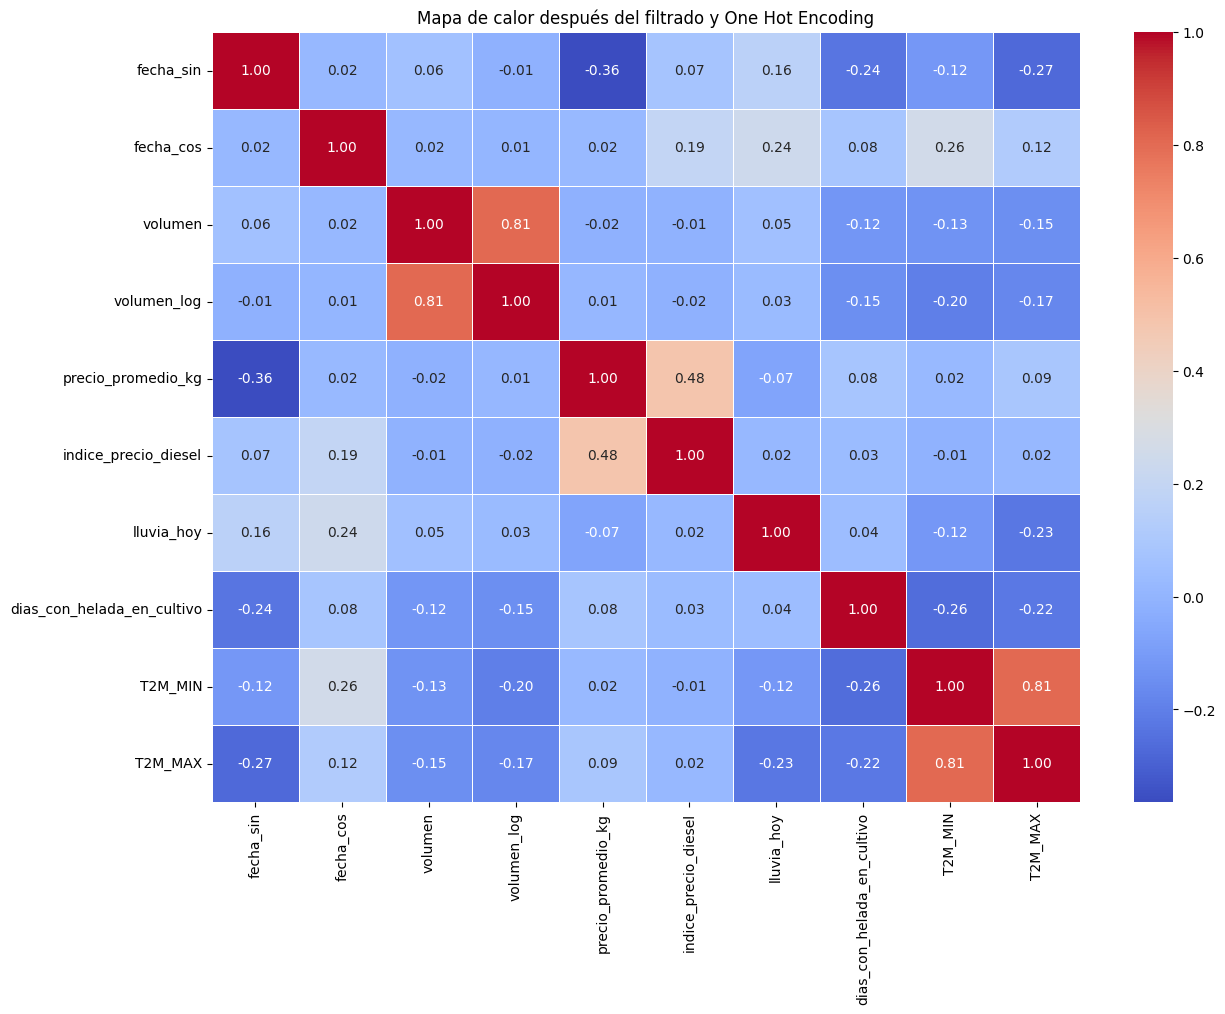

In [11]:
# ==========================================
# 10. Nuevo mapa de calor
# ==========================================

# Seleccionar únicamente columnas numéricas
# Seleccionar únicamente las columnas de interés
df_numericas = df[[
    'fecha_sin',
    'fecha_cos',
    'volumen',
    'volumen_log',
    'precio_promedio_kg',
    'indice_precio_diesel',
    'lluvia_hoy',
    'dias_con_helada_en_cultivo',
    'T2M_MIN',
    'T2M_MAX'
]]

# Calcular correlaciones
corr = df_numericas.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mapa de calor después del filtrado y One Hot Encoding")
plt.show()

In [12]:
# ==========================================
# Guardar el dataset preprocesado
# ==========================================

df.to_csv("Dataset_Preprocesado_Papa_Blanca.csv", index=False, encoding="utf-8-sig")

print("Dataset guardado correctamente como 'Dataset_Preprocesado_Papa_Blanca.csv'")

Dataset guardado correctamente como 'Dataset_Preprocesado_Papa_Blanca.csv'
